In [1]:
# pandas, numpy → data handling
# sklearn → machine learning models + evaluation metrics
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [2]:
# Load Iris dataset (flower classification)
iris = load_iris()
X = iris.data   # features (petal length, width, etc.)
y = (iris.target == 0).astype(int)  # Binary classification: setosa vs not setosa

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [3]:
# Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Logistic Regression model
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [4]:
# Decision Tree metrics
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Precision:", precision_score(y_test, y_pred_dt))
print("Decision Tree Recall:", recall_score(y_test, y_pred_dt))
print("Decision Tree F1:", f1_score(y_test, y_pred_dt))

# Logistic Regression metrics
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Precision:", precision_score(y_test, y_pred_lr))
print("Logistic Regression Recall:", recall_score(y_test, y_pred_lr))
print("Logistic Regression F1:", f1_score(y_test, y_pred_lr))

Decision Tree Accuracy: 1.0
Decision Tree Precision: 1.0
Decision Tree Recall: 1.0
Decision Tree F1: 1.0
Logistic Regression Accuracy: 1.0
Logistic Regression Precision: 1.0
Logistic Regression Recall: 1.0
Logistic Regression F1: 1.0


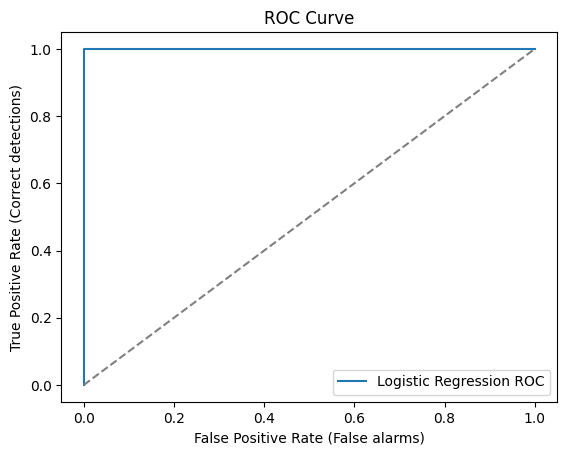

Logistic Regression AUC: 1.0


In [5]:
# Probabilities for Logistic Regression
y_probs = lr_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label="Logistic Regression ROC")
plt.plot([0,1],[0,1],'--', color='gray')  # Random baseline
plt.xlabel("False Positive Rate (False alarms)")
plt.ylabel("True Positive Rate (Correct detections)")
plt.title("ROC Curve")
plt.legend()
plt.show()

# AUC Score
print("Logistic Regression AUC:", roc_auc_score(y_test, y_probs))

In [6]:
# Cross validation for Decision Tree
scores_dt = cross_val_score(dt_model, X, y, cv=5)
print("Decision Tree CV Accuracy:", scores_dt.mean())

# Cross validation for Logistic Regression
scores_lr = cross_val_score(lr_model, X, y, cv=5)
print("Logistic Regression CV Accuracy:", scores_lr.mean())

Decision Tree CV Accuracy: 1.0
Logistic Regression CV Accuracy: 1.0
